# Clustering avec Dino

In [ ]:
%pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 31.6 MB/s eta 0:00:00


90 images trouvées.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/436 [00:00<?, ?B/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


config.json:   0%|          | 0.00/548 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Device set to use cuda:0


Calcul des embeddings DINO-v2…


100%|██████████| 90/90 [03:02<00:00,  2.02s/it]


Clustering en 9 clusters.


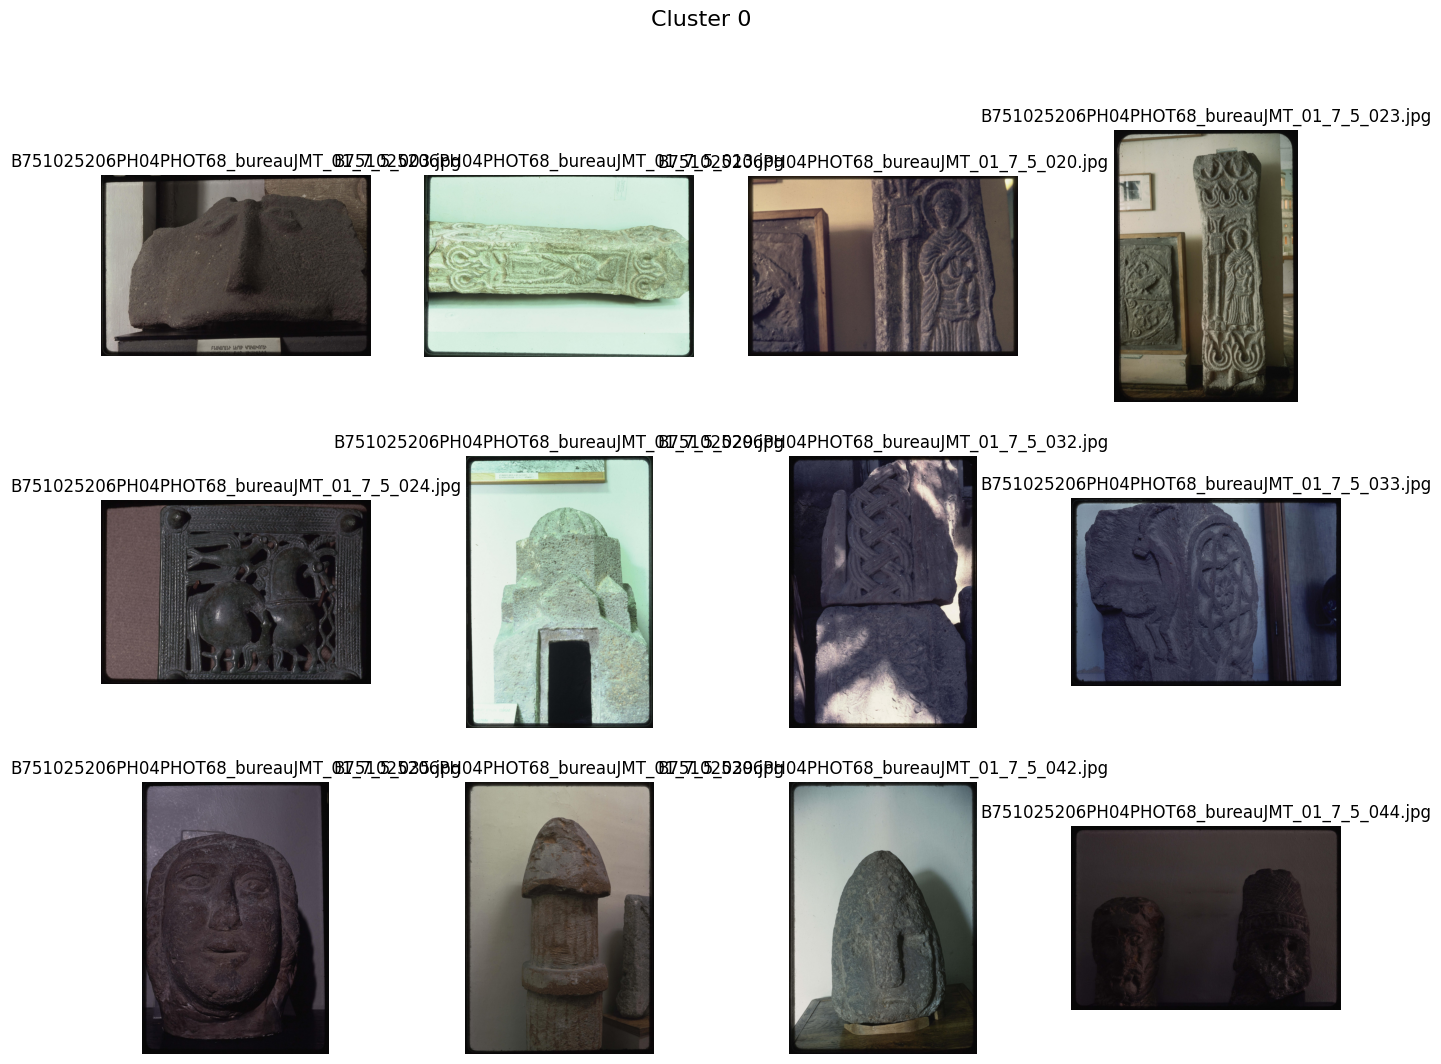

In [ ]:
import os
import numpy as np
import torch
import faiss
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from transformers import AutoImageProcessor, AutoModel, Pipeline

# =========================================================
# CONFIG
# =========================================================

DATASET_DIR = "/content/drive/MyDrive/Computer vision projets/Fonds Thierry/Méthodes non-supervisées/Dataset"
RESULT_DIR = "/content/drive/MyDrive/Computer vision projets/Fonds Thierry/Méthodes non-supervisées/Dataset_clustering_efficientnet"
BATCH_SIZE = 1

os.makedirs(RESULT_DIR, exist_ok=True)

# =========================================================
# PIPELINE DINO-V2
# =========================================================

class DINOv2Pipeline(Pipeline):
    def _sanitize_parameters(self, **kwargs):
        return {}, {}, {}

    def preprocess(self, image):
        # robuste pour images locales
        img = Image.open(image).convert("RGB")
        return self.image_processor(images=img, return_tensors="pt")

    def _forward(self, model_inputs):
        with torch.no_grad():
            return self.model(**model_inputs)

    def postprocess(self, model_outputs):
        # token CLS
        return model_outputs.last_hidden_state[:, 0, :]

# =========================================================
# UTILS
# =========================================================

def collect_images(root):
    images = []
    for r, _, files in os.walk(root):
        for f in files:
            if f.lower().endswith((".jpg", ".jpeg", ".png")):
                images.append(os.path.join(r, f))
    return sorted(images)

def load_dino_pipeline():
    processor = AutoImageProcessor.from_pretrained("facebook/dinov2-base")
    model = AutoModel.from_pretrained("facebook/dinov2-base")
    device = 0 if torch.cuda.is_available() else -1
    return DINOv2Pipeline(
        model=model,
        image_processor=processor,
        device=device
    )

def compute_embeddings(image_paths, pipeline):
    embeddings = []

    for img_path in tqdm(image_paths):
        out = pipeline(img_path)
        embeddings.append(out.detach().cpu())

    embeddings = torch.cat(embeddings, dim=0).numpy()
    return embeddings

def cluster_embeddings(embeddings, n_clusters):
    d = embeddings.shape[1]

    faiss.normalize_L2(embeddings)

    kmeans = faiss.Kmeans(
        d=d,
        k=n_clusters,
        niter=50,
        verbose=True,
        gpu=torch.cuda.is_available()
    )

    kmeans.train(embeddings)
    _, cluster_ids = kmeans.index.search(embeddings, 1)

    return cluster_ids.flatten()

# =========================================================
# VISUALISATION
# =========================================================

def show_cluster(image_paths, cluster_ids, cluster_id, max_images=12):
    idxs = np.where(cluster_ids == cluster_id)[0][:max_images]
    if len(idxs) == 0:
        print(f"Cluster {cluster_id} vide.")
        return

    cols = min(4, len(idxs))
    rows = int(np.ceil(len(idxs) / cols))

    plt.figure(figsize=(4 * cols, 4 * rows))

    for i, idx in enumerate(idxs):
        img = cv2.imread(image_paths[idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.title(os.path.basename(image_paths[idx]))
        plt.axis("off")

    plt.suptitle(f"Cluster {cluster_id}", fontsize=16)
    plt.show()

# =========================================================
# MAIN
# =========================================================

if __name__ == "__main__":

    images = collect_images(DATASET_DIR)
    print(f"{len(images)} images trouvées.")

    pipeline = load_dino_pipeline()

    emb_path = os.path.join(RESULT_DIR, "dino_embeddings.npy")

    if os.path.exists(emb_path):
        print("Chargement des embeddings depuis le cache.")
        embeddings = np.load(emb_path)
    else:
        print("Calcul des embeddings DINO-v2…")
        embeddings = compute_embeddings(images, pipeline)
        np.save(emb_path, embeddings)

    # Heuristique standard
    N_CLUSTERS = int(np.sqrt(len(images)))
    print(f"Clustering en {N_CLUSTERS} clusters.")

    cluster_ids = cluster_embeddings(embeddings.astype(np.float32), N_CLUSTERS)

    # Exemple de visualisation
    show_cluster(images, cluster_ids, cluster_id=0)


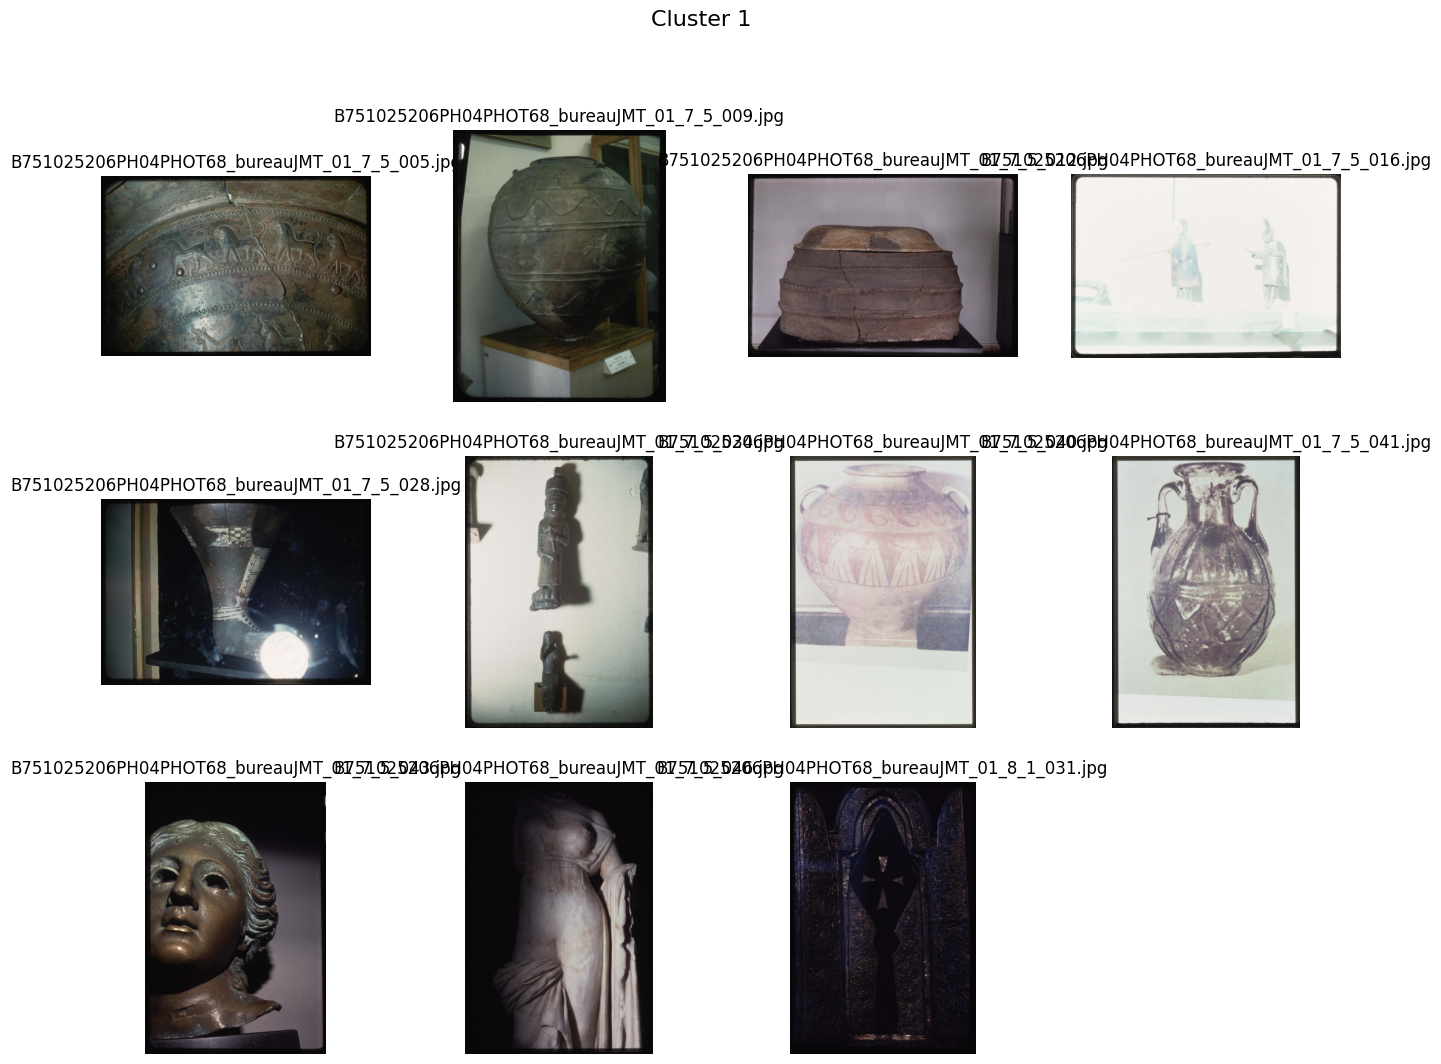

In [ ]:
 show_cluster(images, cluster_ids, cluster_id=1)

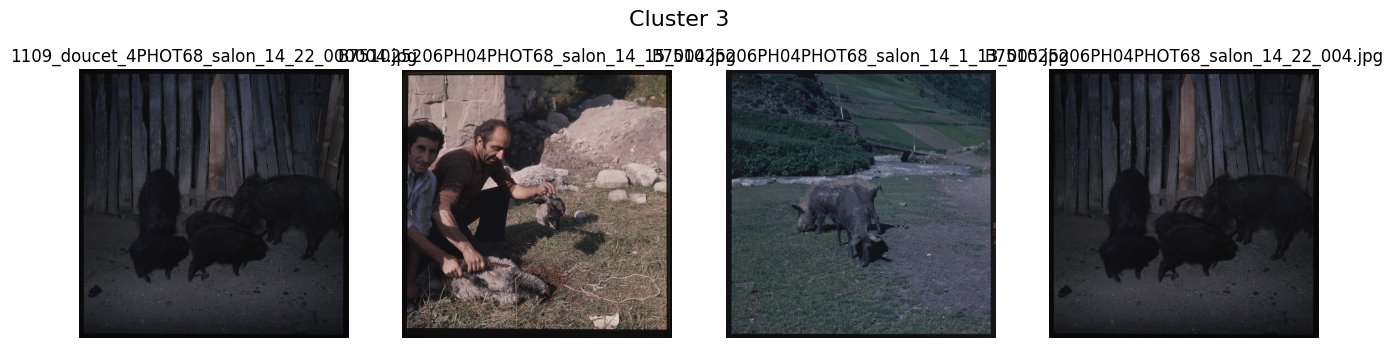

In [ ]:
show_cluster(images, cluster_ids, cluster_id=3)

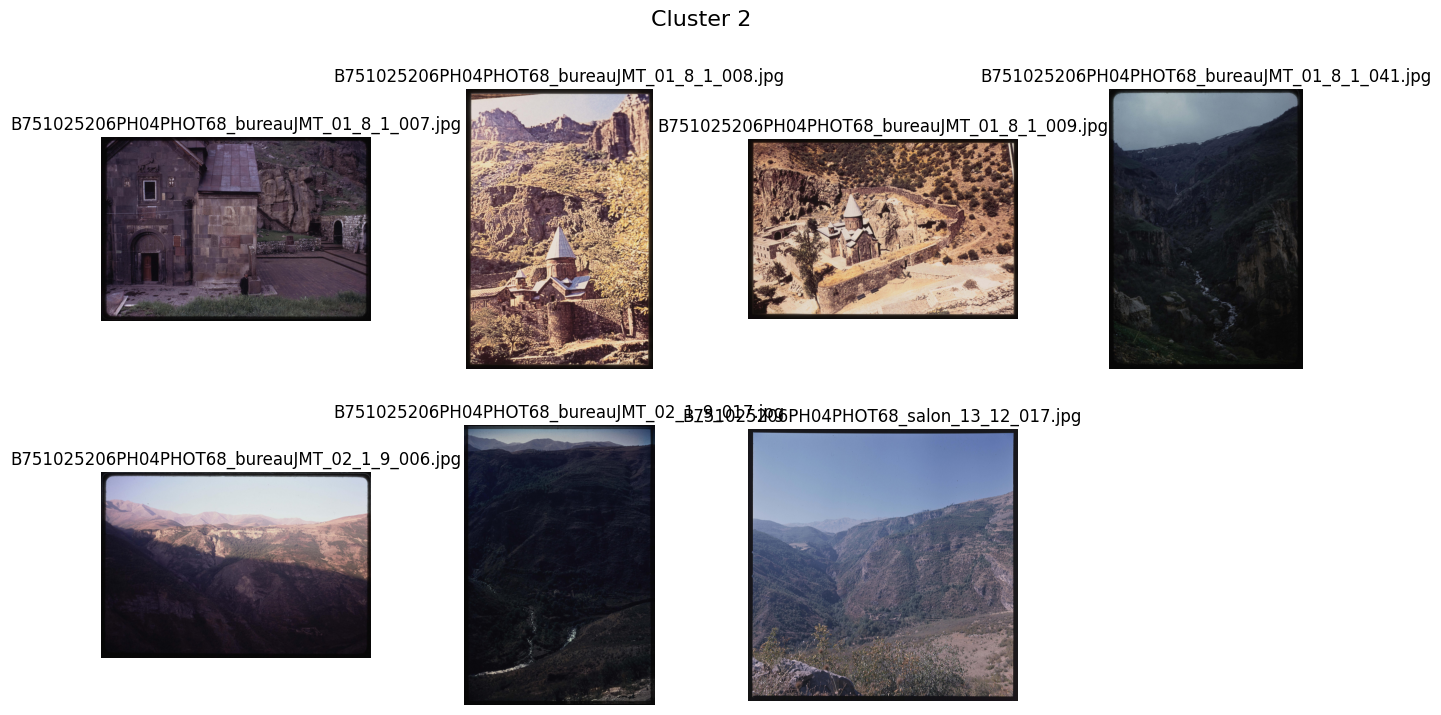

In [ ]:
show_cluster(images, cluster_ids, cluster_id=2)

In [ ]:
import pandas as pd
import os

# ============================================
# EXPORT CSV (solo nome file)
# ============================================

rows = []

for img_path, cluster_id in zip(images, cluster_ids):
    filename = os.path.basename(img_path)   # solo nome file

    rows.append({
        "title": filename,
        "image_url": img_path,
        "clustering_id": int(cluster_id)
    })

df = pd.DataFrame(rows)

csv_path = os.path.join(RESULT_DIR, "/content/drive/MyDrive/Computer vision projets/Fonds Thierry/clustering_results_dino.csv")
df.to_csv(csv_path, index=False)

print(f"CSV salvato in: {csv_path}")

CSV salvato in: /content/drive/MyDrive/Computer vision projets/Fonds Thierry/clustering_results_dino.csv
